In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

rfm = pd.read_csv("../data/rfm_result.csv", index_col="Customer ID")
print(f"客户数：{len(rfm):,}")
rfm[["Recency", "Frequency", "Monetary"]].describe().round(1)

客户数：5,878


,Recency,Frequency,Monetary
count,5878.0,5878.0,5878.0
mean,201.3,6.3,3018.6
std,209.3,13.0,14737.7
min,1.0,1.0,3.0
25%,26.0,1.0,348.8
50%,96.0,3.0,898.9
75%,380.0,7.0,2307.1
max,739.0,398.0,608821.6


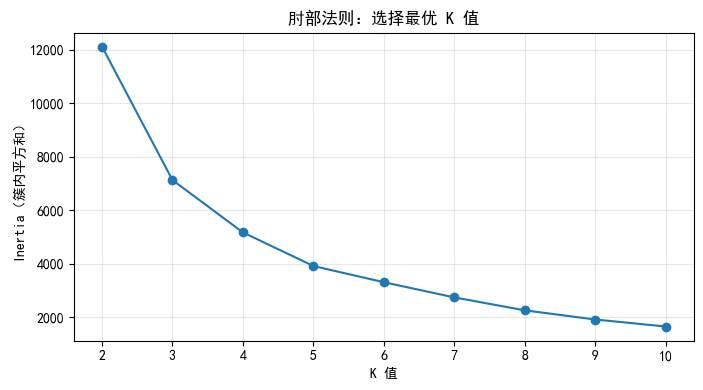

In [6]:
# 标准化（K-Means对量纲敏感，必须标准化）
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[["Recency", "Frequency", "Monetary"]])

# 肘部法则：测试 K=2 到 K=10
inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, marker="o")
plt.xlabel("K 值")
plt.ylabel("Inertia（簇内平方和）")
plt.title("肘部法则：选择最优 K 值")
plt.xticks(list(K_range))
plt.grid(True, alpha=0.3)
plt.show()

## 选择 K=5
- 肘部法则显示 K=4~5 之间下降速度明显变缓，再增加 K 收益有限
- K=5 与 RFM 手动分层的群体数量接近，方便交叉对比

In [7]:
km = KMeans(n_clusters=5, random_state=42, n_init=10)
rfm["Cluster"] = km.fit_predict(rfm_scaled)

cluster_summary = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(1)
cluster_summary["人数"] = rfm.groupby("Cluster").size()
print(cluster_summary)

         Recency  Frequency  Monetary    人数
Cluster                                    
0           28.1       28.5   13935.2   383
1          471.2        2.2     755.7  1917
2           22.5      119.8  100927.0    24
3            3.5      212.5  436835.8     4
4           75.7        5.1    1912.1  3550


In [8]:
cluster_names = {
    0: "优质活跃客户",
    1: "沉睡低价值客户",
    2: "超级大客户",
    3: "极端VIP（疑似批发）",
    4: "一般活跃客户"
}
rfm["聚类标签"] = rfm["Cluster"].map(cluster_names)

# 对比展示
cluster_summary["标签"] = cluster_summary.index.map(cluster_names)
print(cluster_summary[["标签", "人数", "Recency", "Frequency", "Monetary"]])

                  标签    人数  Recency  Frequency  Monetary
Cluster                                                 
0             优质活跃客户   383     28.1       28.5   13935.2
1            沉睡低价值客户  1917    471.2        2.2     755.7
2              超级大客户    24     22.5      119.8  100927.0
3        极端VIP（疑似批发）     4      3.5      212.5  436835.8
4             一般活跃客户  3550     75.7        5.1    1912.1


In [9]:
# RFM标签 vs K-Means聚类 交叉表
cross = pd.crosstab(rfm["用户标签"], rfm["聚类标签"])
print(cross)

聚类标签      一般活跃客户  优质活跃客户  极端VIP（疑似批发）  沉睡低价值客户  超级大客户
用户标签                                                 
一般客户         731       0            0      371      0
新客户          442       0            0        0      1
沉睡客户         197       0            0     1326      0
流失风险一般价值      40       0            0       86      0
流失风险高价值       83       9            0      134      1
潜力客户         943      32            0        0      0
高价值忠诚客户      932     342            4        0     22
高频低消客户       182       0            0        0      0


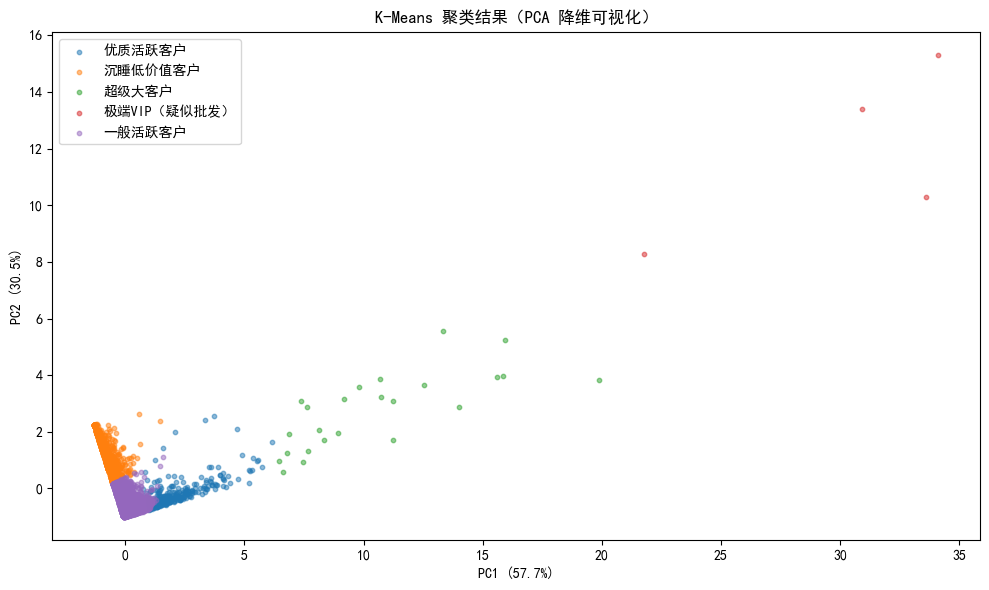

In [10]:
from sklearn.decomposition import PCA

# 用PCA降到2维来可视化
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

plt.figure(figsize=(10, 6))
for cluster_id, name in cluster_names.items():
    mask = rfm["Cluster"] == cluster_id
    plt.scatter(rfm_pca[mask, 0], rfm_pca[mask, 1], label=name, alpha=0.5, s=10)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.title("K-Means 聚类结果（PCA 降维可视化）")
plt.legend()
plt.tight_layout()
plt.show()

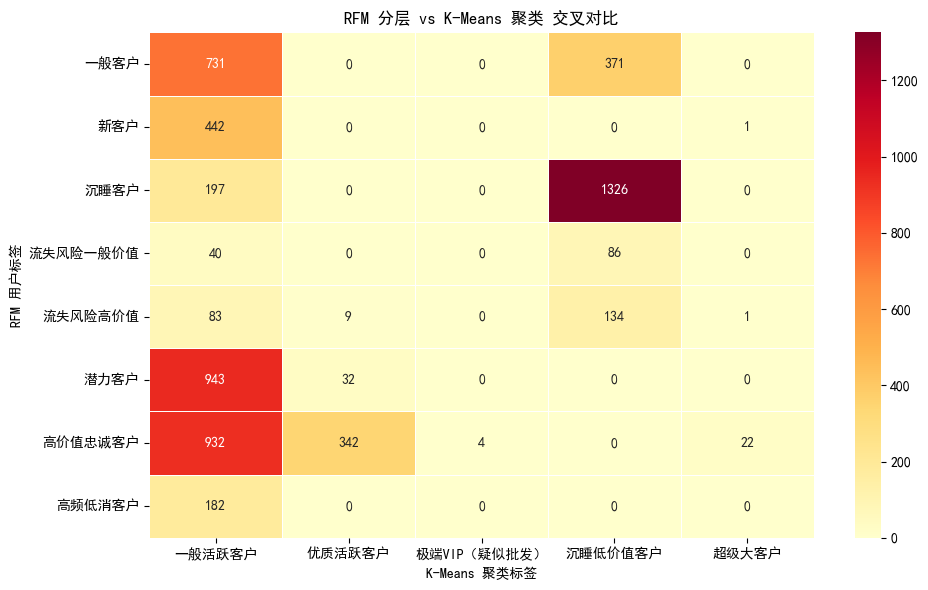

In [13]:
import seaborn as sns

cross = pd.crosstab(rfm["用户标签"], rfm["聚类标签"])

plt.figure(figsize=(10, 6))
sns.heatmap(cross, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5)
plt.title("RFM 分层 vs K-Means 聚类 交叉对比")
plt.ylabel("RFM 用户标签")
plt.xlabel("K-Means 聚类标签")
plt.tight_layout()
plt.show()

In [14]:
rfm.to_csv("../data/rfm_clustered.csv")
print("已保存带聚类标签的 RFM 结果")

已保存带聚类标签的 RFM 结果
